<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Machine_Learning_Fundamentals_Feature_Engineering_and_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the Synthetic Data Vault (SDV) for synthetic data generation
# and ensure imbalanced-learn is updated for SMOTE and Tomek Links
!pip install sdv imbalanced-learn -q

# Import core data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles for clean visuals
sns.set_theme(style="whitegrid")
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.2 MB/s eta 0:00:00


In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

print("Original dataset shape:", X.shape)

# Stratify=y ensures that the train and test sets have the same percentage of samples
# of each target class as the complete set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Original dataset shape: (150, 4)
Training set shape: (105, 4)
Testing set shape: (45, 4)


In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Initialize Scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# --- Min-Max Scaling ---
# fit_transform learns the min/max from training data and transforms it
X_train_minmax = min_max_scaler.fit_transform(X_train)
# transform applies the learned training parameters to the test data
X_test_minmax = min_max_scaler.transform(X_test)

# --- Z-score Standardization ---
X_train_std = standard_scaler.fit_transform(X_train)
X_test_std = standard_scaler.transform(X_test)

# Convert back to DataFrame just for structural comparison demonstration
df_minmax_demo = pd.DataFrame(X_train_minmax, columns=X.columns)
df_std_demo = pd.DataFrame(X_train_std, columns=X.columns)

print("Min-Max scaled sample (Notice range [0, 1]):")
print(df_minmax_demo.head(2))
print("\nStandardized sample (Notice Mean ≈ 0, Std ≈ 1):")
print(df_std_demo.head(2))

Min-Max scaled sample (Notice range [0, 1]):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.208333           0.327586          0.416667
1           0.527778          0.083333           0.586207          0.583333

Standardized sample (Notice Mean ≈ 0, Std ≈ 1):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900459         -1.220248          -0.441986         -0.136610
1           0.380366         -1.879558           0.402829          0.380294


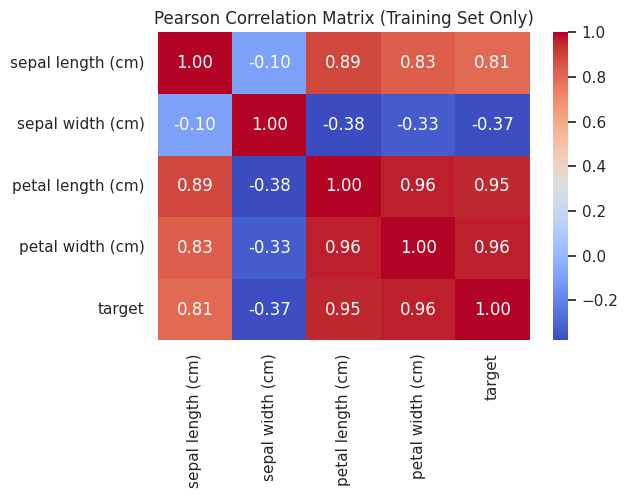

In [4]:
# Combine X_train and y_train temporarily to check feature-to-target correlation
train_comb = pd.concat([X_train, y_train], axis=1)
corr_matrix = train_comb.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Matrix (Training Set Only)")
plt.show()

# Drop features with high collinearity if needed (e.g., petal length & petal width)

In [6]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Initialize a base classifier
estimator = RandomForestClassifier(n_estimators=50, random_state=42)

# Select the top 2 features
selector = RFE(estimator, n_features_to_select=2, step=1)
selector = selector.fit(X_train, y_train)

# Boolean mask of selected features
selected_features = X_train.columns[selector.support_]
print("RFE Selected Features:", list(selected_features))

RFE Selected Features: ['petal length (cm)', 'petal width (cm)']


In [7]:
from sklearn.linear_model import LogisticRegression

# penalty='l1' triggers LASSO. solver='liblinear' supports L1 optimization.
# C is inverse regularization strength; smaller values mean stronger regularization (more zeros).
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.4, random_state=42)
lasso_model.fit(X_train_std, y_train)

print("LASSO Coefficients per class:")
for i, coef in enumerate(lasso_model.coef_):
    print(f"Class {i} Coefficients: {np.round(coef, 4)}")
# Features with 0.0 coefficients are ignored by the model for that class

LASSO Coefficients per class:
Class 0 Coefficients: [ 0.      0.8119 -3.081   0.    ]
Class 1 Coefficients: [ 0.     -1.2765  0.      0.    ]
Class 2 Coefficients: [0.     0.     0.     3.5706]


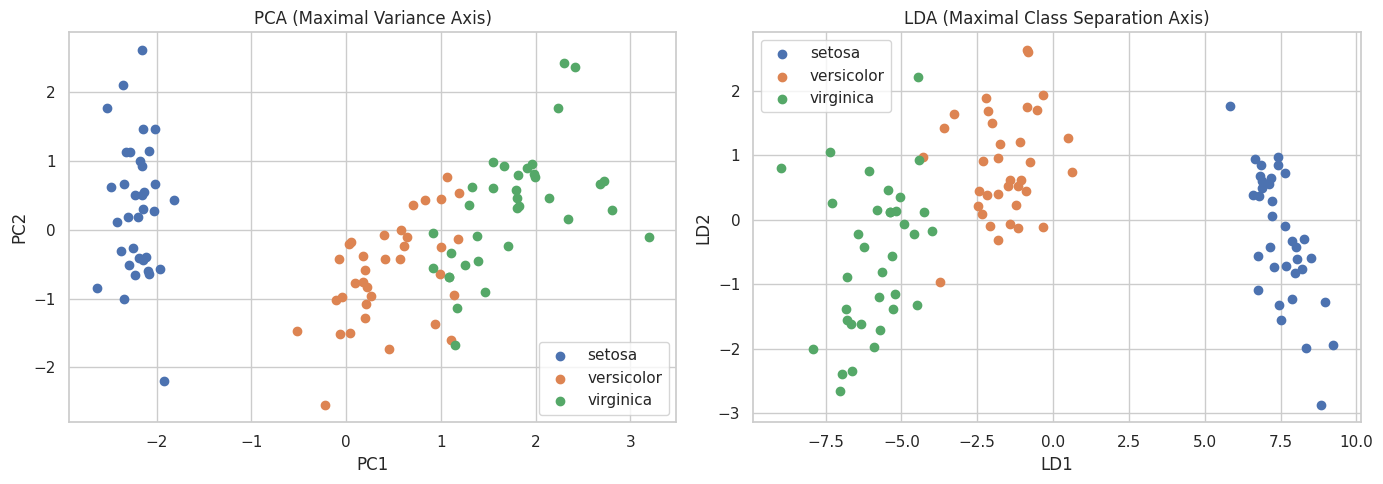

In [8]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)

# Apply LDA (requires target labels because it is supervised)
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)

# Plotting Comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# PCA Plot
for i, target_name in enumerate(iris.target_names):
    ax[0].scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], label=target_name)
ax[0].set_title('PCA (Maximal Variance Axis)')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].legend()

# LDA Plot
for i, target_name in enumerate(iris.target_names):
    ax[1].scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=target_name)
ax[1].set_title('LDA (Maximal Class Separation Axis)')
ax[1].set_xlabel('LD1')
ax[1].set_ylabel('LD2')
ax[1].legend()

plt.tight_layout()
plt.show()

In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

# Create artificial severe imbalance (Drop most of Class 0)
keep_indices = (y_train != 0) | (X_train.index % 5 == 0)
X_imb = X_train[keep_indices.values]
y_imb = y_train[keep_indices.values]
print("Imbalanced Class distribution:\n", y_imb.value_counts())

# --- Upsampling with SMOTE ---
smote = SMOTE(random_state=42)
X_resampled_up, y_resampled_up = smote.fit_resample(X_imb, y_imb)
print("\nAfter SMOTE Upsampling:\n", y_resampled_up.value_counts())

# --- Downsampling with NearMiss ---
nearmiss = NearMiss(version=1)
X_resampled_down, y_resampled_down = nearmiss.fit_resample(X_imb, y_imb)
print("\nAfter NearMiss Downsampling:\n", y_resampled_down.value_counts())

Imbalanced Class distribution:
 target
1    35
2    35
0     6
Name: count, dtype: int64

After SMOTE Upsampling:
 target
1    35
2    35
0    35
Name: count, dtype: int64

After NearMiss Downsampling:
 target
0    6
1    6
2    6
Name: count, dtype: int64


In [17]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Prepare metadata directly out of our DataFrame structure
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_comb)

# Initialize the synthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the data distribution
synthesizer.fit(train_comb)

# Generate 50 completely unique synthetic rows
synthetic_data = synthesizer.sample(num_rows=50)

print("Generated Synthetic Data Sample:")
print(synthetic_data.head(3))

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Generated Synthetic Data Sample:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                6.2               2.5                6.7               2.2   
1                5.5               3.2                2.6               0.4   
2                5.8               2.1                4.5               1.6   

   target  
0       0  
1       0  
2       1  


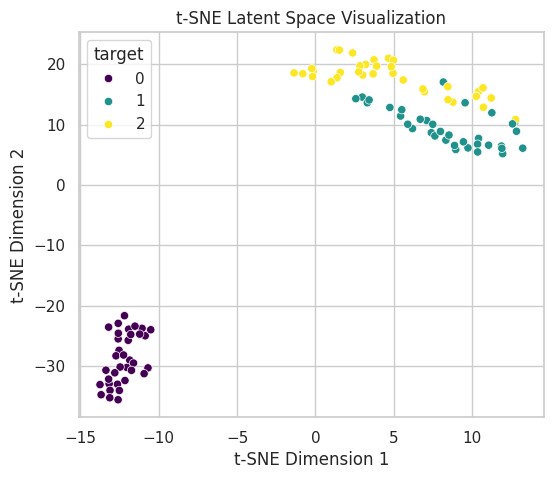

In [18]:
from sklearn.manifold import TSNE

# Perplexity relates to the number of nearest neighbors used in optimization
# Learning rate usually ranges between 10 to 1000
tsne = TSNE(n_components=2, perplexity=15, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_train_std)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train, palette='viridis', legend='full')
plt.title("t-SNE Latent Space Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()